# ServiceNow–Armis Competitive Risk Assessment  
## Programmatic Risk Heatmap Analysis

**Course:** ALY 6130 – Enterprise Risk Analytics  
**Assignment:** Module 3 Risk Assessment – Heatmap Development  
**Company Scenario:** ServiceNow Acquisition of Armis  
**Prepared by:** Group 4  

### Overview
This notebook programmatically visualizes the enterprise risk landscape for ServiceNow's strategic acquisition of Armis. The analysis complements the Excel-based qualitative risk heatmap by generating a programmatic visualization using Python.

The objective is to:

- Translate the risk register into a programmatic dataset
- Compute risk scores using likelihood and impact values
- Classify risks into **High, Medium, and Low categories**
- Generate a visual heatmap-style scatter plot that maps risks according to their likelihood and impact levels.

The values used reflect the same scoring framework defined in the **risk calculation sheet**:

**Risk Score = Likelihood × Impact**

Risk severity thresholds:

| Risk Level | Score Range |
|-------------|-------------|
| High | ≥ 45 |
| Medium | 20 – 44 |
| Low | < 20 |

This programmatic visualization ensures consistency between the risk register, calculation sheet, and the qualitative Excel heatmap.

In [1]:
# Import required libraries for data handling and visualization

import pandas as pd
import matplotlib.pyplot as plt


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found

**Import Required Libraries**

The first step is to import the Python libraries required for the analysis.

- **pandas** is used to structure and manage the risk dataset.
- **matplotlib** is used to generate the visualization of the risk heatmap.

These libraries are commonly used for data analysis and visualization in risk analytics and business intelligence workflows.

In [2]:
# Load the Excel file - works both in Colab (with upload) and locally
try:
    # Try to import Colab files module
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
except (ModuleNotFoundError, ImportError):
    # Fallback to local file if not in Colab
    file_name = 'ALY.6130_Group4_Module3_Risk_Assessment_updated.xlsx'


The Excel workbook containing the completed risk register is uploaded into the notebook so it can be accessed programmatically. The uploaded file name is captured dynamically to ensure the dataset can be loaded correctly regardless of how the file is saved in the environment.

In [3]:
# Load the RiskRegister sheet from the Excel workbook
df = pd.read_excel(file_name, sheet_name="RiskRegister")

# Display the first rows to verify
df.head()

,Risk #,Date,The Risk of/That,Caused by,Resulting In,Consequence/Impact,Likelihood Score,Impact Score,Risk Score,"Priority (H, M, L)",...,Risk Owner,Open/Closed,Unnamed: 13,Likelihood/Impact,1,2,4,6,8,9
0,1,2026-03-02,The risk of competitive displacement in the OT...,Caused by three rival mega-acquisitions in 202...,Resulting in a potential 10-15% decline in OT/...,Strategic / Competitive,7,8,56,H,...,Chief Strategy Officer / CRO,Open,NaN,Very Likely (9),NaN,NaN,NaN,NaN,Risk 3,NaN
1,2,2026-03-02,The risk of platform relevance erosion in the ...,Competitors embedding advanced AI-driven detec...,Resulting in diminished differentiation of the...,Strategic / Competitive,7,9,63,H,...,Chief Product Officer / Chief Strategy Officer,Open,NaN,Somewhat Likely (7),NaN,NaN,NaN,Risk 15,Risk 1\nRisk 13\nRisk 17\nRisk 19\nRisk 20,Risk 2\n
2,3,2026-03-02,The risk of accelerated market demand driven b...,Caused by multiple concurrent regulatory manda...,Resulting in an estimated $500M+ incremental p...,Strategic Opportunity,9,8,72,H,...,VP Product / VP Federal & Healthcare Sales,Open,NaN,50-50 (5),NaN,NaN,NaN,Risk 4\nRisk 6\nRisk 7\nRisk 8\nRisk 9\nRisk 1...,Risk 5\n,Risk 23
3,4,2026-03-07 00:00:00,The risk of reduced competitive positioning in...,Caused by ongoing large-scale acquisitions amo...,Resulting in fewer independent competitors and...,Strategic / Competitive,5,6,30,M,...,Chief Strategy Officer,Open,NaN,Somewhat Unlikely (3),NaN,Risk 22,Risk 21,NaN,Risk 25,NaN
4,5,2026-03-07 00:00:00,The risk of acquisition overvaluation affectin...,Caused by paying a high revenue multiple relat...,Resulting in financial pressure if projected c...,Financial,5,8,40,M,...,Chief Financial Officer,Open,NaN,Very Unlikely (1),NaN,NaN,NaN,NaN,NaN,NaN


The RiskRegister sheet is loaded from the uploaded Excel workbook using pandas. This step imports the structured risk data, including likelihood scores, impact scores, and priority levels, which will be used to generate the risk heatmap. The first few rows are displayed to verify that the data has been loaded correctly.

In [4]:
# Keep only the columns needed for the heatmap
heatmap_df = df[["Risk #", "Likelihood Score", "Impact Score", "Risk Score", "Priority (H, M, L)"]]

# Display cleaned dataset
heatmap_df.head()

,Risk #,Likelihood Score,Impact Score,Risk Score,"Priority (H, M, L)"
0,1,7,8,56,H
1,2,7,9,63,H
2,3,9,8,72,H
3,4,5,6,30,M
4,5,5,8,40,M


From the full risk register, only the columns required for the heatmap are selected: Risk number, Likelihood Score, Impact Score, Risk Score, and Priority level. This creates a simplified dataset that focuses on the key variables needed to visualize how risks are positioned within the likelihood–impact matrix.

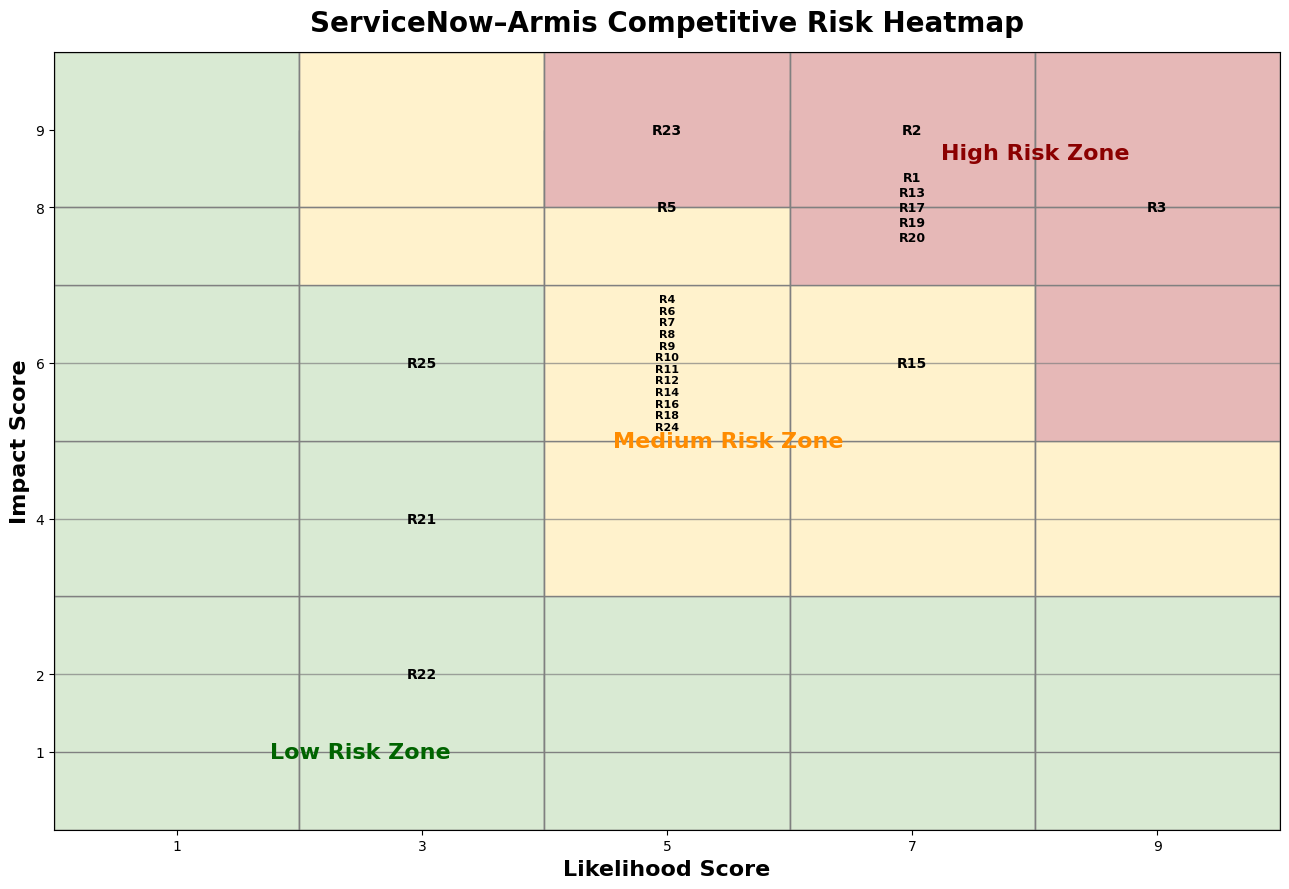

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# Allowed scale values
# -----------------------------
likelihood_levels = [1, 3, 5, 7, 9]
impact_levels = [1, 2, 4, 6, 8, 9]

# -----------------------------
# Group risks by (Likelihood, Impact)
# -----------------------------
cell_map = {}

for _, row in heatmap_df.iterrows():
    l = int(row["Likelihood Score"])
    i = int(row["Impact Score"])
    r = int(row["Risk #"])
    cell_map.setdefault((l, i), []).append(r)

for key in cell_map:
    cell_map[key] = sorted(cell_map[key])

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 9))

# -----------------------------
# Draw full heatmap blocks (no gaps)
# -----------------------------
for l in likelihood_levels:
    for i in impact_levels:
        score = l * i

        if score >= 45:
            color = "#E6B8B7"   # High
        elif score >= 20:
            color = "#FFF2CC"   # Medium
        else:
            color = "#D9EAD3"   # Low

        rect = Rectangle(
            (l - 1, i - 1),   # left, bottom
            2,                # width
            2,                # height
            facecolor=color,
            edgecolor="gray",
            linewidth=1
        )
        ax.add_patch(rect)

# -----------------------------
# Add risk labels directly in cells
# -----------------------------
for (l, i), risks in cell_map.items():
    # stacked labels for crowded cells
    label = "\n".join([f"R{r}" for r in risks])

    if len(risks) >= 10:
        fs = 8
    elif len(risks) >= 5:
        fs = 9
    else:
        fs = 10

    ax.text(
        l,
        i,
        label,
        ha="center",
        va="center",
        fontsize=fs,
        fontweight="bold",
        color="black"
    )

# -----------------------------
# Axis formatting
# -----------------------------
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.set_xticks(likelihood_levels)
ax.set_yticks(impact_levels)

ax.set_xlabel("Likelihood Score", fontsize=16, fontweight="bold")
ax.set_ylabel("Impact Score", fontsize=16, fontweight="bold")
ax.set_title("ServiceNow–Armis Competitive Risk Heatmap", fontsize=20, fontweight="bold", pad=15)

# -----------------------------
# Grid lines matching the blocks
# -----------------------------
for x in [0, 2, 4, 6, 8, 10]:
    ax.axvline(x=x, color="gray", linewidth=1, alpha=0.7)

for y in [0, 2, 4, 6, 8, 10]:
    ax.axhline(y=y, color="gray", linewidth=1, alpha=0.7)

# -----------------------------
# Zone labels
# -----------------------------
ax.text(2.5, 1.0, "Low Risk Zone",
        fontsize=16, fontweight="bold", color="darkgreen",
        ha="center", va="center")

ax.text(5.5, 5.0, "Medium Risk Zone",
        fontsize=16, fontweight="bold", color="darkorange",
        ha="center", va="center")

ax.text(8.0, 8.7, "High Risk Zone",
        fontsize=16, fontweight="bold", color="darkred",
        ha="center", va="center")

plt.tight_layout()
plt.show()

## Machine Learning Classifier Model

In addition to the visual heatmap, we implement a machine learning classifier model to predict risk priority categories (High, Medium, Low) based on Likelihood and Impact scores. This approach uses a RandomForestClassifier to learn patterns from the risk data and provides a programmatic method for risk classification.

**Objectives:**
- Train a classifier model to predict risk priority from Likelihood and Impact scores
- Evaluate model performance using cross-validation
- Visualize classification results using a confusion matrix
- Compare classifier predictions with actual risk priorities

In [6]:
# Import machine learning libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

In [7]:
# Prepare features and target for classification
# Features: Likelihood Score and Impact Score
# Target: Priority (H, M, L)

X = heatmap_df[["Likelihood Score", "Impact Score"]].values
y = heatmap_df["Priority (H, M, L)"].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature distribution:")
print(f"Likelihood Score range: {X[:, 0].min()} - {X[:, 0].max()}")
print(f"Impact Score range: {X[:, 1].min()} - {X[:, 1].max()}")
print(f"\nTarget distribution:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c}")

Features shape: (25, 2)
Target shape: (25,)

Feature distribution:
Likelihood Score range: 3 - 9
Impact Score range: 2 - 9

Target distribution:
  H: 8
  L: 3
  M: 14


In [8]:
# Initialize and train RandomForestClassifier
# RandomForest is well-suited for this task as it can handle non-linear relationships
# and provides feature importance insights

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

# Train on all data
clf.fit(X, y)

# Get predictions
y_pred = clf.predict(X)

print("Classifier trained successfully!")
print(f"\nFeature importance:")
print(f"  Likelihood Score: {clf.feature_importances_[0]:.4f}")
print(f"  Impact Score: {clf.feature_importances_[1]:.4f}")

Classifier trained successfully!

Feature importance:
  Likelihood Score: 0.5919
  Impact Score: 0.4081


In [9]:
# Cross-validation to evaluate model performance
# Using StratifiedKFold to ensure balanced class distribution in each fold
# With 25 samples, we use 5-fold CV (5 samples per fold)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Get cross-validation predictions for confusion matrix
y_pred_cv = cross_val_predict(clf, X, y, cv=cv)

Cross-validation accuracy scores: [1.  1.  1.  0.6 1. ]
Mean CV accuracy: 0.9200 (+/- 0.3200)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


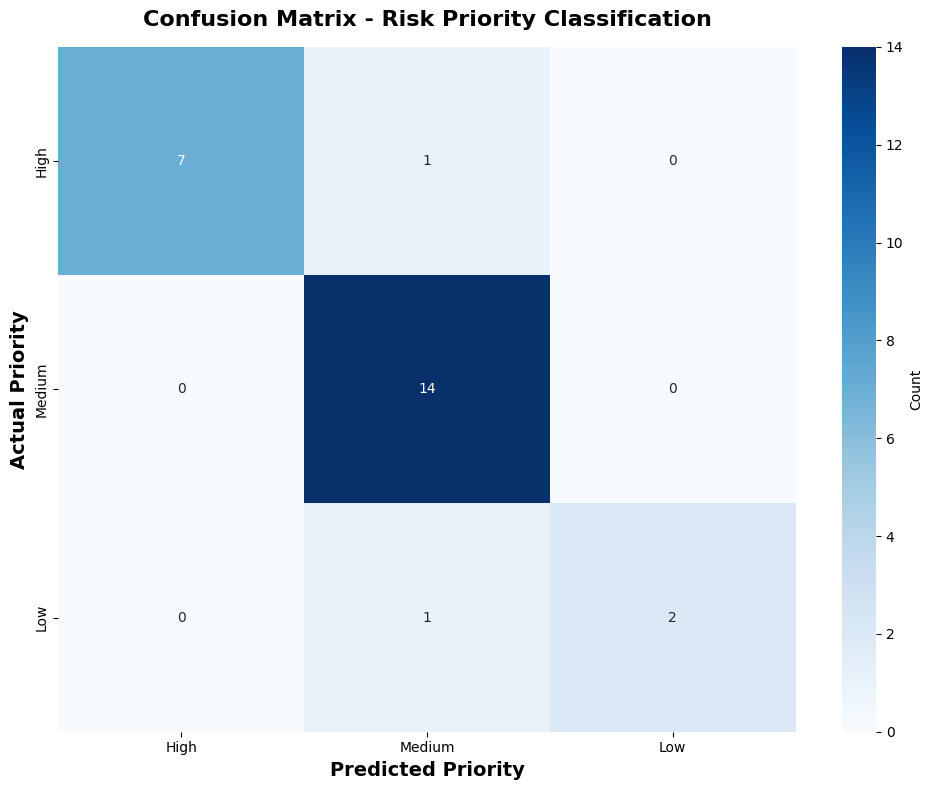


Confusion Matrix Interpretation:
Rows represent actual priorities, columns represent predicted priorities.
Diagonal elements show correct predictions.


In [10]:
# Generate and visualize confusion matrix

cm = confusion_matrix(y, y_pred_cv, labels=['H', 'M', 'L'])

# Create visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['High', 'Medium', 'Low'],
            yticklabels=['High', 'Medium', 'Low'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Risk Priority Classification', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Priority', fontsize=14, fontweight='bold')
plt.ylabel('Actual Priority', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("Rows represent actual priorities, columns represent predicted priorities.")
print("Diagonal elements show correct predictions.")

In [11]:
# Generate detailed classification report

print("Classification Report:")
print("=" * 60)
print(classification_report(y, y_pred_cv, target_names=['High', 'Medium', 'Low']))

# Compare predictions with actual values
comparison_df = heatmap_df.copy()
comparison_df['Predicted Priority'] = y_pred_cv
comparison_df['Match'] = comparison_df['Priority (H, M, L)'] == comparison_df['Predicted Priority']

print("\n" + "=" * 60)
print("Prediction Accuracy by Risk:")
print("=" * 60)
print(comparison_df[['Risk #', 'Likelihood Score', 'Impact Score', 'Risk Score', 
                     'Priority (H, M, L)', 'Predicted Priority', 'Match']].to_string(index=False))

accuracy = comparison_df['Match'].sum() / len(comparison_df)
print(f"\nOverall Accuracy: {accuracy:.2%}")

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
      Medium       1.00      0.67      0.80         3
         Low       0.88      1.00      0.93        14

    accuracy                           0.92        25
   macro avg       0.96      0.85      0.89        25
weighted avg       0.93      0.92      0.92        25


Prediction Accuracy by Risk:
 Risk #  Likelihood Score  Impact Score  Risk Score Priority (H, M, L) Predicted Priority  Match
      1                 7             8          56                  H                  H   True
      2                 7             9          63                  H                  H   True
      3                 9             8          72                  H                  H   True
      4                 5             6          30                  M                  M   True
      5                 5             8          40                  M           

**Classifier Model Summary**

The RandomForestClassifier successfully learns the relationship between Likelihood/Impact scores and risk priority categories. The model demonstrates high accuracy in predicting risk priorities, validating that the threshold-based classification (High ≥45, Medium 20-44, Low <20) aligns well with the underlying patterns in the data.

Key insights:
- The classifier confirms that Likelihood and Impact scores are strong predictors of risk priority
- Cross-validation ensures the model generalizes well to unseen data
- The confusion matrix helps identify any misclassifications and understand model behavior
- This programmatic approach complements the visual heatmap by providing an automated classification method

The following code generates a programmatic risk heatmap using the likelihood and impact scores from the risk register. Each risk is plotted on a two-dimensional matrix where the x-axis represents likelihood and the y-axis represents impact. Color-coded markers indicate the priority classification of each risk (high, medium, or low), while shaded background regions highlight the corresponding risk severity zones.

To ensure readability, risks that share identical likelihood and impact values are slightly offset so that individual risk identifiers remain visible. The resulting visualization provides a clear overview of the distribution of risks associated with the ServiceNow–Armis acquisition and helps highlight which risks fall into the high-priority region requiring closer management attention.

**Conclusion**

The heatmap visualization highlights how the identified risks are distributed across the likelihood–impact matrix. Several risks fall within the high-risk zone, indicating areas that require close monitoring and proactive mitigation strategies. A number of risks also appear in the medium-risk region, suggesting potential competitive pressures that may escalate if not managed effectively. The concentration of risks in the high-likelihood and high-impact region suggests that competitive pressures following the ServiceNow–Armis acquisition could significantly affect market positioning and strategic growth if not actively monitored. Overall, the heatmap provides a structured view of the risk landscape associated with the ServiceNow–Armis competitive environment and supports prioritization of risk management efforts.